In [ ]:
import pandas as pd

df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

print(df.head())
print(df.info())
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:")
print(df.duplicated().sum())
print("\nTarget Distribution:")
print(df['Churned'].value_counts(normalize=True))

    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9                     9.0   
1     

In [2]:
print("Unique values in Country:", df['Country'].nunique())
print("Unique values in City:", df['City'].nunique())
print("Unique values in Signup_Quarter:", df['Signup_Quarter'].nunique())
print("Unique values in Gender:", df['Gender'].nunique())

Unique values in Country: 8
Unique values in City: 40
Unique values in Signup_Quarter: 4
Unique values in Gender: 3


Logistic Regression Accuracy: 0.7757
Random Forest Accuracy: 0.9104

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7110
           1       0.92      0.76      0.83      2890

    accuracy                           0.91     10000
   macro avg       0.91      0.87      0.88     10000
weighted avg       0.91      0.91      0.91     10000



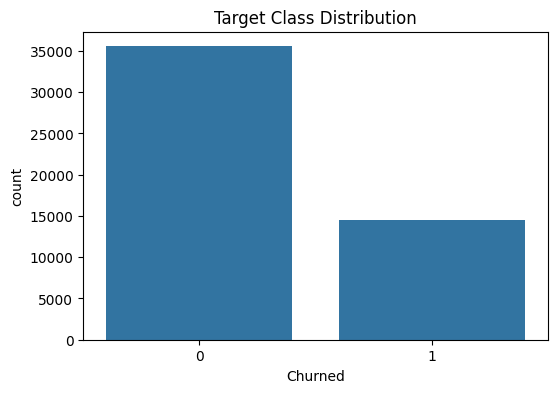

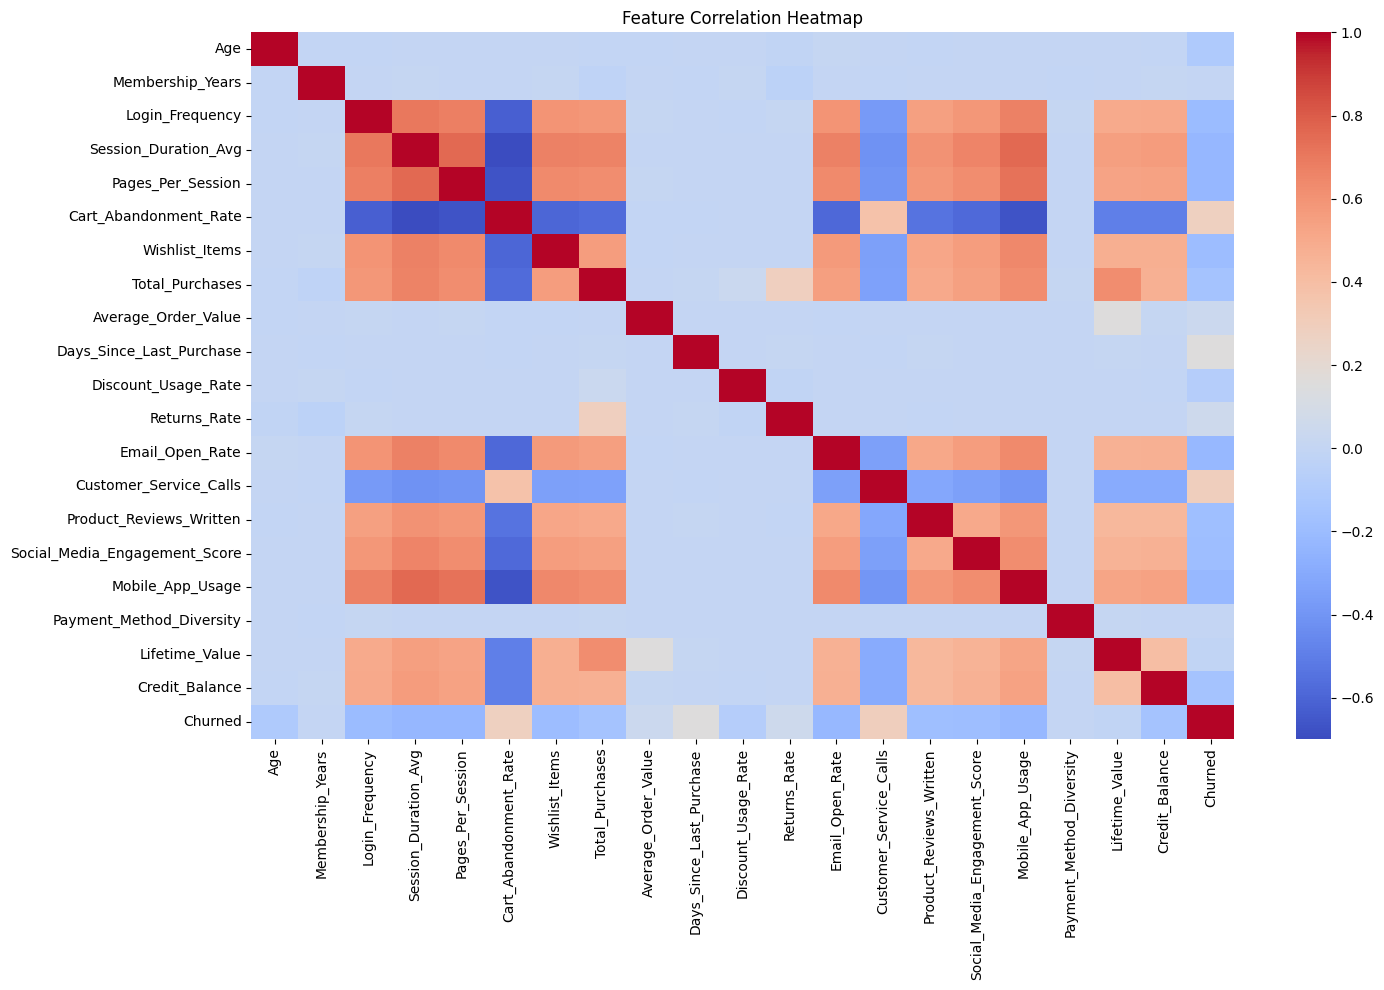

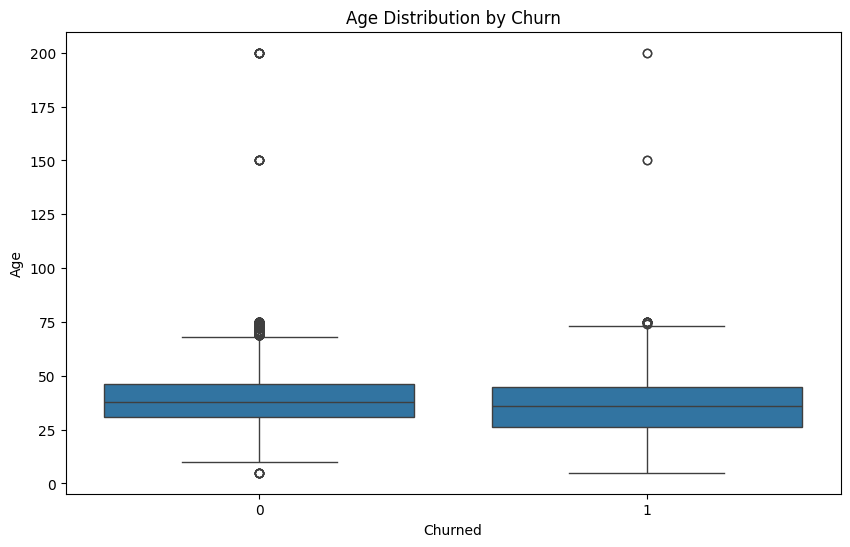

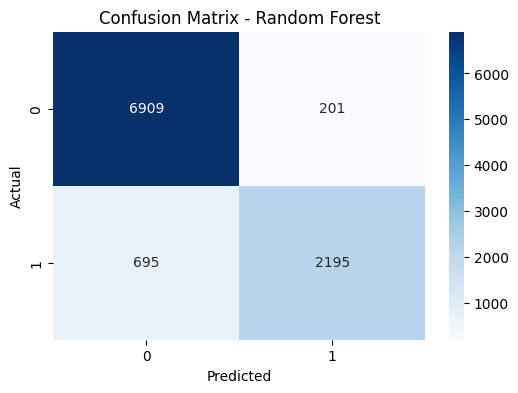

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.figure(figsize=(6, 4))
sns.countplot(x='Churned', data=df)
plt.title('Target Class Distribution')
plt.savefig('target_distribution.png')

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 10))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churned', y='Age', data=df)
plt.title('Age Distribution by Churn')
plt.savefig('age_churn_boxplot.png')

X = df.drop(columns=['Churned'])
y = df['Churned']

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Logistic Regression
lr_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(max_iter=1000))])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# Random Forest
rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix_rf.png')

# Classification Report
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))